# C5.3 Huygens’ Principle

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C5.3.1 Motivation: Why Do We Need a New Way to Think About Light?

In ray optics, light is treated as **straight-line paths** that reflect or refract. But this model fails when we look at:

- **Shadows** that have soft, blurry edges
- **Laser beams** that spread over long distances
- **Single-slit experiments** that produce complex patterns
- **Interference fringes** that require the waves to interact

To make sense of these, we need to stop thinking of light as just a "ray" and start thinking of it as a **wave** that spreads, overlaps, and diffracts.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C5.3.2 Huygens’ Principle (Expanded)

### Core Idea

> Every point on a wavefront acts as a **source of new spherical wavelets**.  
> The wavefront at a later time is the **tangent surface** (or envelope) of all these secondary wavelets.

This idea lets us **construct** how a wavefront advances over time, even around edges or through slits.

### Visualizing It

Imagine a **snapshot** of a wavefront — say, a straight line (plane wave) or a circle (spherical wave). According to Huygens:

- Every point on that wavefront emits a **tiny circular ripple** (in 2D) or a spherical wave (in 3D).
- After a short time interval $ \Delta t $, these ripples have radius $ v \Delta t $, where $ v $ is the wave speed.
- The **new wavefront** is the curve (or surface) that just touches the outer edges of all those ripples.

This construction is powerful because:
- It works **without solving** any differential equations.
- It provides **geometrical insight** into reflection, refraction, and diffraction.

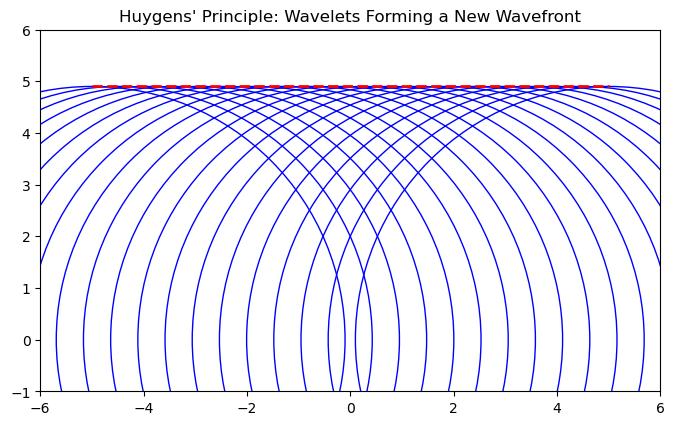

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Parameters
num_points = 20
wave_speed = 1.0
time_steps = 50
x_start, x_end = -5, 5
y_wavefront = 0

# Initial wavefront points
x_points = np.linspace(x_start, x_end, num_points)
y_points = np.full_like(x_points, y_wavefront)

# Plot setup
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(-6, 6)
ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.set_title("Huygens' Principle: Wavelets Forming a New Wavefront")
wavelet_circles = [plt.Circle((x, y), 0, color='blue', fill=False, lw=1) for x, y in zip(x_points, y_points)]
for circle in wavelet_circles:
    ax.add_patch(circle)

# Envelope line
envelope_line, = ax.plot([], [], 'r--', lw=2)

def init():
    for c in wavelet_circles:
        c.set_radius(0)
    envelope_line.set_data([], [])
    return wavelet_circles + [envelope_line]

def animate(frame):
    t = frame * 0.1
    r = wave_speed * t
    for c in wavelet_circles:
        c.set_radius(r)
    envelope_line.set_data([x_start, x_end], [y_wavefront + r, y_wavefront + r])
    return wavelet_circles + [envelope_line]

ani = animation.FuncAnimation(fig, animate, frames=time_steps, init_func=init, blit=True, interval=100)
HTML(ani.to_jshtml())


### Key Characteristics

- Each wavelet travels at the **speed of the wave** in that medium.
- The **direction of the new wavefront** depends on how fast wavelets expand in different regions.
- The **shape of the new wavefront** is dictated by the geometry of the original wave and the environment (barriers, openings, media).

### ⚠️ Common Misconceptions

- **Huygens wavelets are not real emissions** like photons — they are a **mathematical tool** to reconstruct the wavefront.
- The secondary wavelets **interfere** with each other to produce the final result — this wasn't part of Huygens’ original model but was added later by **Fresnel**.


### Fresnel Refinement: Huygens-Fresnel Principle

Huygens' model lacked the concept of **interference**. Fresnel improved it by adding:

> The new wavefront is the result of **constructive and destructive interference** among all secondary wavelets, **including their phase**.

This explained:
- Why **some directions are dark** (destructive interference)
- Why diffraction patterns form
- Why wavelets behind a wavefront don’t cancel the wave entirely


### Why It Works: A Physics Perspective

We now understand that Huygens’ Principle emerges from the **wave equation** itself. It’s not magic — it’s a **geometrical interpretation** of how waves behave.

If you solve the wave equation using **Green’s functions**, you’ll find that the field at a later time can be expressed as a **sum of influences** from nearby points — very much like Huygens' idea.

So while the principle is classical and geometric, it foreshadows how **fields evolve** in space and time.


### Summary Table

| Feature                    | Description                                  |
|---------------------------|----------------------------------------------|
| Wavelet source            | Each point on wavefront                      |
| Wavelet shape             | Spherical (or circular in 2D)                |
| New wavefront             | Tangent surface to all wavelets              |
| Speed of wavelets         | Equal to wave speed in medium                |
| Limitation of original    | No interference or directionality            |
| Fresnel improvement       | Adds interference and phase consideration    |
| Modern interpretation     | Emerges from wave equation & Green’s function |


### Useful for Modeling:

- **Reflection**: mirror geometry conserves wavelet speed and path
- **Refraction**: different speeds shift wavelet reach → wavefront bends
- **Diffraction**: only some wavelets survive → wavefront bends around edges
- **Interference**: overlapping wavelets from multiple sources create fringe patterns


> 🔹 Huygens’ Principle turns a **pointwise model** into a **global wavefront**, revealing the heart of wave propagation.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C5.3.3 The Deeper Physics: Where Huygens’ Principle Fits

Huygens’ principle was originally a geometric rule — but we now know it emerges from **solving the wave equation**.

### Classical Wave Equation:

For any scalar wave field \( u(x,t) \), we have:

$$
\nabla^2 u - \frac{1}{v^2} \frac{\partial^2 u}{\partial t^2} = 0
$$

Solutions to this equation **naturally spread** — and the idea of each point generating new waves aligns with **how the solution propagates** in space and time.


### Maxwell's Equations (Light as an EM Wave)

In electromagnetism, light obeys Maxwell’s equations. In vacuum, they reduce to:

$$
\nabla^2 \vec{E} - \mu_0 \varepsilon_0 \frac{\partial^2 \vec{E}}{\partial t^2} = 0
$$

This is a **vector wave equation** for the electric field \( \vec{E} \). The solution propagates like ripples — justifying the Huygens construction.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C5.3.4 Connection to Modern Field Theory and Quantum Physics

### Wave Propagation as a Field Effect

In **quantum field theory (QFT)**, fields (like the electromagnetic field) don’t just move — they **propagate disturbances** at finite speeds.

- Every point in space contains a “field value”
- A change at one point influences nearby points — like spherical wavelets

This is conceptually similar to Huygens’ idea: **each point is a new source** of influence.

### Path Integrals: Many Paths = Interference

In **quantum field theory**, Richard Feynman showed that particles don’t just take one path — they take **every possible path**, and their contributions **interfere**.

> In a sense, each point on the wavefront acts as a **new launch point** for possible future trajectories — conceptually very similar to Huygens’ secondary wavelets.

Huygens’ principle, though classical, **prefigures the idea of quantum superposition**: each contribution interferes with all others to build the observed outcome.

---

### Green’s Functions (Mathematical Analogy)

In solving differential equations (like the wave equation), we use **Green’s functions** — which are the responses to a delta-function source.

- Placing a point source at every location (like Huygens' secondary sources)
- Adding their responses reproduces the full field

So in modern math and physics, Huygens’ principle is echoed in the idea that:

> “You can build up a complex solution by summing over simpler local influences.”


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C5.3.5 Summary of Physical Implications

| Concept         | What Huygens Tells Us                                    |
|------------------|----------------------------------------------------------|
| **Reflection**   | Wavelets bounce symmetrically — mirror law arises        |
| **Refraction**   | Slower speed = shorter radius → bends wavefront          |
| **Diffraction**  | Sharp edges still emit wavelets — waves bend into shadows |
| **Interference** | Wavelets overlap — intensities combine                   |
| **Quantum Theory** | Many "paths" interfere — echoes of secondary sources   |

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C5.3.6 Summary

- **Huygens' Principle** treats wavefronts as ensembles of **local wavelet sources**.
- It's a powerful geometrical model of wave behavior.
- It **anticipates deeper ideas** from differential equations, field theory, and quantum mechanics.
- It sets up our understanding of **interference** and **diffraction**, which we explore next.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C5.3.7 Next Up

We’ll now use Huygens’ principle to understand how overlapping wavelets from **multiple slits** produce **interference patterns** — and derive their geometry and spacing.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">